# 論文再現バックテスト + 検証レイヤー

**対象論文**: 中川他 (2025)「部分空間正則化付き主成分分析を用いた日米業種リードラグ投資戦略」
**ユニバース**: 26 銘柄固定（米国 9・日本 17、XLC / XLRE 除外） — 要件定義書 v3 §2.1
**判定方針**: 合否は論文の R/R 一致ではなく、**IC・分位スプレッド・ルックアヘッド監査**（要件定義書 v3 §4）で判定する。R/R 値はあくまで参考値。

## 構成

| サブセクション | 内容 |
|---|---|
| 2A（本ファイル先頭） | データ取得・共通営業日インターセクション |
| 2B | リターン定義（CC / OC） |
| 2C | 事前相関 C_full・バックテストループ |
| 2D | 検証レイヤー（IC・分位スプレッド・ルックアヘッド監査） — 合否判定の核心 |
| 2E | パフォーマンス評価と論文比較 |


In [1]:
# SECTION 2A — Imports & settings
import os
import sys
import time
import warnings
from datetime import datetime, date

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Make src/ importable (this notebook lives in notebooks/)
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.universe import (
    ALL_TICKERS, US_TICKERS, JP_TICKERS,
    N_US, N_JP, N_TOTAL,
    get_universe_masks,
    US_SECTOR_NAMES, JP_SECTOR_NAMES,
)
from src.pca_engine import (
    build_prior_subspace,
    build_target_correlation,
    compute_regularized_correlation,
    extract_top_eigenvectors,
    compute_lead_lag_signal,
)

# Reproducibility
RNG_SEED = 20260515
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")

print("Repo root:", REPO_ROOT)
print("Python   :", sys.version.split()[0])
print("numpy    :", np.__version__)
print("pandas   :", pd.__version__)
print("yfinance :", yf.__version__)


Repo root: /Users/tamairyoga/Desktop/MacBook Pro/システム開発/sector-leadlag
Python   : 3.11.15
numpy    : 2.4.4
pandas   : 3.0.3
yfinance : 1.3.0


In [2]:
# SECTION 2A — Universe check
assert N_US == 9 and N_JP == 17 and N_TOTAL == 26, "Universe must be 9 + 17 = 26 (v3)"
print(f"Universe: N_US={N_US}, N_JP={N_JP}, total={N_TOTAL}")
print(f"US_TICKERS ({N_US}):", US_TICKERS)
print(f"JP_TICKERS ({N_JP}):", JP_TICKERS)

masks = get_universe_masks()
for k, m in masks.items():
    on = [t for t, v in zip(US_TICKERS if k.startswith("us") else JP_TICKERS, m) if v]
    print(f"  {k:13s} shape={m.shape}, true_count={int(m.sum())} -> {on}")


Universe: N_US=9, N_JP=17, total=26
US_TICKERS (9): ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']
JP_TICKERS (17): ['1617.T', '1618.T', '1619.T', '1620.T', '1621.T', '1622.T', '1623.T', '1624.T', '1625.T', '1626.T', '1627.T', '1628.T', '1629.T', '1630.T', '1631.T', '1632.T', '1633.T']
  us_cyclical   shape=(9,), true_count=3 -> ['XLB', 'XLE', 'XLF']
  us_defensive  shape=(9,), true_count=4 -> ['XLK', 'XLP', 'XLU', 'XLV']
  jp_cyclical   shape=(17,), true_count=4 -> ['1618.T', '1625.T', '1629.T', '1631.T']
  jp_defensive  shape=(17,), true_count=4 -> ['1617.T', '1621.T', '1627.T', '1630.T']


In [3]:
# SECTION 2A — Data fetch (auto_adjust=True, Open & Close, with cache & retry)
#
# Cache format: a single MultiIndex CSV with columns (field, ticker) where
# field ∈ {"Open", "Close"} and ticker iterates ALL_TICKERS. The CSV header
# spans two rows so pandas can round-trip the MultiIndex losslessly.

START_DATE = pd.Timestamp("2010-01-01")
END_DATE   = pd.Timestamp("2025-12-31")
TODAY      = pd.Timestamp(date.today())
# We can't fetch data beyond today; the effective upper bound is min(END_DATE, today).
EFFECTIVE_END = min(END_DATE, TODAY)
# Tolerate up to 7 calendar-day staleness in the cache (weekends / holidays).
STALENESS_TOL = pd.Timedelta(days=7)

CACHE_PATH = os.path.join(REPO_ROOT, "data", "cache_prices.csv")
os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)


def _download_with_retry(tickers, start, end, max_retries=3):
    last_err = None
    for attempt in range(max_retries):
        try:
            df = yf.download(
                tickers,
                start=start,
                end=end,
                auto_adjust=True,
                progress=False,
                threads=True,
                group_by="column",
            )
            if df is None or df.empty:
                raise RuntimeError("yfinance returned an empty DataFrame")
            return df
        except Exception as exc:
            last_err = exc
            wait = 2 ** attempt  # 1s -> 2s -> 4s
            print(f"  [retry {attempt + 1}/{max_retries}] {exc!r}; sleeping {wait}s")
            time.sleep(wait)
    raise RuntimeError(f"yfinance download failed after {max_retries} retries: {last_err}")


def _load_cache(path):
    # First two rows of the file are the MultiIndex column header
    df = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=["field", "ticker"])
    return df


def _save_cache(df, path):
    df.to_csv(path)


raw = None
use_cache = os.path.exists(CACHE_PATH)
if use_cache:
    try:
        cached = _load_cache(CACHE_PATH)
        cached_start = cached.index.min()
        cached_end   = cached.index.max()
        covers_start   = cached_start <= START_DATE
        covers_end     = cached_end   >= (EFFECTIVE_END - STALENESS_TOL)
        covers_tickers = set(ALL_TICKERS).issubset(set(cached.columns.get_level_values("ticker")))
        if covers_start and covers_end and covers_tickers:
            print(f"Using cache: {CACHE_PATH}")
            print(f"  range  : {cached_start.date()} … {cached_end.date()}, rows={len(cached)}")
            raw = cached
        else:
            reason = []
            if not covers_start:   reason.append(f"start>{START_DATE.date()}")
            if not covers_end:     reason.append(f"end<{(EFFECTIVE_END - STALENESS_TOL).date()}")
            if not covers_tickers: reason.append("tickers missing")
            print(f"Cache exists but is stale ({', '.join(reason)}); refetching.")
            use_cache = False
    except Exception as exc:
        print(f"Cache read failed ({exc!r}); refetching.")
        use_cache = False

if not use_cache or raw is None:
    # yfinance's `end` is exclusive; pad by 1 day so we get the latest available bar.
    fetch_end = (EFFECTIVE_END + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    fetch_start = START_DATE.strftime("%Y-%m-%d")
    print(f"Downloading {len(ALL_TICKERS)} tickers from yfinance: {fetch_start} … {fetch_end}")
    downloaded = _download_with_retry(ALL_TICKERS, fetch_start, fetch_end)

    # yfinance returns a MultiIndex (field, ticker). Keep only Open & Close.
    if isinstance(downloaded.columns, pd.MultiIndex):
        fields = downloaded.columns.get_level_values(0).unique().tolist()
        if "Open" not in fields or "Close" not in fields:
            raise RuntimeError(f"Expected Open & Close columns; got fields={fields}")
        open_df  = downloaded["Open"][ALL_TICKERS].copy()
        close_df = downloaded["Close"][ALL_TICKERS].copy()
    else:
        # Single-ticker shortcut (shouldn't happen for 26 tickers)
        raise RuntimeError("Unexpected single-level columns from yfinance")

    raw = pd.concat(
        {"Open": open_df, "Close": close_df},
        axis=1,
        names=["field", "ticker"],
    )
    raw.index.name = "Date"
    _save_cache(raw, CACHE_PATH)
    print(f"Cache written: {CACHE_PATH}  ({len(raw)} rows)")

# Split into per-field DataFrames for downstream use
open_raw  = raw["Open"][ALL_TICKERS].copy()
close_raw = raw["Close"][ALL_TICKERS].copy()
open_raw.index  = pd.to_datetime(open_raw.index)
close_raw.index = pd.to_datetime(close_raw.index)

print(f"open_raw  shape: {open_raw.shape}")
print(f"close_raw shape: {close_raw.shape}")
print(f"date range     : {close_raw.index.min().date()} … {close_raw.index.max().date()}")


Cache exists but is stale (start>2010-01-01); refetching.
Cache written: /Users/tamairyoga/Desktop/MacBook Pro/システム開発/sector-leadlag/data/cache_prices.csv  (4160 rows)
open_raw  shape: (4160, 26)
close_raw shape: (4160, 26)
date range     : 2010-01-04 … 2025-12-31


In [4]:
# SECTION 2A — Common business-day intersection (requirements_v3 §3.2)
# Rule: keep only dates where every one of the 26 tickers has a non-null Close.
# Align Open to that same date set.

non_null_close = close_raw.notna().all(axis=1)
common_dates = close_raw.index[non_null_close]

close_df = close_raw.loc[common_dates].copy()
open_df  = open_raw.loc[common_dates].copy()

# Open may still have NaN even when Close is non-null (rare). Audit it.
open_missing = open_df.isna().sum().sum()
if open_missing > 0:
    # Drop those rows too (consistent intersection between Open & Close)
    both_non_null = open_df.notna().all(axis=1) & close_df.notna().all(axis=1)
    common_dates = close_df.index[both_non_null]
    close_df = close_df.loc[common_dates].copy()
    open_df  = open_df.loc[common_dates].copy()
    print(f"NOTE: {open_missing} Open cells were NaN; intersected with Open availability too.")

N_BIZ = len(common_dates)
print(f"採用期間：{common_dates.min().date()} 〜 {common_dates.max().date()}, 共通営業日数：{N_BIZ}")

# Audit: consecutive NaN runs in the *raw* close per ticker (before intersection)
def _max_consecutive_nan_run(s: pd.Series) -> int:
    nan = s.isna().astype(int).values
    best = run = 0
    for x in nan:
        run = run + 1 if x else 0
        if run > best:
            best = run
    return best

gap_report = {t: _max_consecutive_nan_run(close_raw[t]) for t in ALL_TICKERS}
worst = sorted(gap_report.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("\nMax consecutive NaN runs in raw Close (top 10):")
for t, n in worst:
    flag = "  ← ⚠️ ≥3" if n >= 3 else ""
    print(f"  {t:8s}: {n:3d} days{flag}")

flagged = [t for t, n in gap_report.items() if n >= 3]
if flagged:
    print(f"\n⚠️  WARNING: tickers with ≥3 consecutive NaN in raw Close: {flagged}")
    print("    These are tolerated (intersection removes them) but worth knowing.")
else:
    print("\nOK: no ticker has a ≥3-day consecutive NaN run in raw Close.")


採用期間：2010-01-04 〜 2025-12-30, 共通営業日数：3796

Max consecutive NaN runs in raw Close (top 10):
  1617.T  :   6 days  ← ⚠️ ≥3
  1618.T  :   6 days  ← ⚠️ ≥3
  1619.T  :   6 days  ← ⚠️ ≥3
  1620.T  :   6 days  ← ⚠️ ≥3
  1621.T  :   6 days  ← ⚠️ ≥3
  1622.T  :   6 days  ← ⚠️ ≥3
  1623.T  :   6 days  ← ⚠️ ≥3
  1624.T  :   6 days  ← ⚠️ ≥3
  1625.T  :   6 days  ← ⚠️ ≥3
  1626.T  :   6 days  ← ⚠️ ≥3

⚠️  WARNING: tickers with ≥3 consecutive NaN in raw Close: ['1617.T', '1618.T', '1619.T', '1620.T', '1621.T', '1622.T', '1623.T', '1624.T', '1625.T', '1626.T', '1627.T', '1628.T', '1629.T', '1630.T', '1631.T', '1632.T', '1633.T']
    These are tolerated (intersection removes them) but worth knowing.


## セル 5 の結果を読む

- **採用期間**：おおむね 2010-01-04 〜 2025 年後半（取得時点で利用可能な営業日まで）をカバーしているはず。
  XLC（2018 年上場）と XLRE（2015 年上場）を除外しているため、v2 のように 2018 年以降まで短縮されることは無い。
- **共通営業日数**：日米同時取引日のみのため、年あたり概ね 240 日前後 × 15〜16 年 ≒ 3,600〜3,800 日が想定範囲。
  もしこれを大きく下回る（例: 1,000 日台に短縮）場合は、26 銘柄以外が混入していないか、もしくは特定銘柄の長期欠損を疑う。
- **連続 3 営業日以上の欠損**：警告として可視化する。インターセクション後は除外されるが、原因（祝日連続・取引停止・配信遅延）を把握しておく。

問題なければ SECTION 2B（リターン定義）に進む。


In [5]:
# SECTION 2B — Close-to-Close returns (PCA estimation input)
# r_cc[i, t] = Close[i, t] / Close[i, t-1] - 1
# auto_adjust=True なので Close は配当・分割調整済み（要件定義書 v3 §2.4）

cc_returns = close_df.pct_change()  # shape (N_BIZ, 26), 最初の行は NaN

assert cc_returns.shape == (N_BIZ, N_TOTAL), (
    f"cc_returns shape {cc_returns.shape} != expected ({N_BIZ}, {N_TOTAL})"
)
assert cc_returns.iloc[0].isna().all(), "First row of cc_returns must be all NaN"
assert cc_returns.iloc[1:].notna().all().all(), (
    "cc_returns has NaN beyond the first row — inspect close_df"
)

# Outlier audit (≥50% daily move). Requirements v3 §3.3: warn only, do not stop.
extreme_cc = (cc_returns.abs() > 0.50).sum().sort_values(ascending=False)
n_extreme_cc = int(extreme_cc.sum())
print(f"cc_returns shape: {cc_returns.shape}")
print(f"  rows with ≥1 ticker |CC| > 50%: {int((cc_returns.abs() > 0.50).any(axis=1).sum())}")
print(f"  total cell-count of |CC| > 50%: {n_extreme_cc}")
if n_extreme_cc > 0:
    nz = extreme_cc[extreme_cc > 0]
    print(f"  tickers with ≥1 extreme CC: {nz.to_dict()}")
else:
    print("  no extreme CC return detected (>50%).")


cc_returns shape: (3796, 26)
  rows with ≥1 ticker |CC| > 50%: 2
  total cell-count of |CC| > 50%: 2
  tickers with ≥1 extreme CC: {'1629.T': 2}


In [6]:
# SECTION 2B — Open-to-Close returns (strategy P/L, Japan side only)
# r_oc[j, t] = Close[j, t] / Open[j, t] - 1   ※ 同一営業日 t の調整後始値→終値
# 戦略は時点 t に米国 CC で生成したシグナルを、日本側 t+1 の OC で執行・評価する。
# v2 で使っていた「日本側 CC リターンで近似」は廃止（要件定義書 v3 §2.4）。

jp_open  = open_df[JP_TICKERS]
jp_close = close_df[JP_TICKERS]
oc_returns_jp = jp_close / jp_open - 1.0

assert oc_returns_jp.shape == (N_BIZ, N_JP), (
    f"oc_returns_jp shape {oc_returns_jp.shape} != expected ({N_BIZ}, {N_JP})"
)
n_nan_oc = int(oc_returns_jp.isna().sum().sum())
assert n_nan_oc == 0, (
    f"oc_returns_jp must not contain NaN (same-day Open/Close); "
    f"found {n_nan_oc} NaN cells — inspect open_df / close_df alignment."
)

# Outlier audit (Requirements v3 §3.3)
extreme_oc = (oc_returns_jp.abs() > 0.50).sum().sort_values(ascending=False)
n_extreme_oc = int(extreme_oc.sum())
print(f"oc_returns_jp shape: {oc_returns_jp.shape}")
print(f"  rows with ≥1 ticker |OC| > 50%: {int((oc_returns_jp.abs() > 0.50).any(axis=1).sum())}")
print(f"  total cell-count of |OC| > 50%: {n_extreme_oc}")
if n_extreme_oc > 0:
    nz = extreme_oc[extreme_oc > 0]
    print(f"  tickers with ≥1 extreme OC: {nz.to_dict()}")
else:
    print("  no extreme OC return detected (>50%).")

# Quick descriptive stats (mean & std, annualised with 252)
daily_mean = oc_returns_jp.mean()
daily_std  = oc_returns_jp.std()
print("\nDaily OC return summary (Japan, 17 tickers):")
print(f"  mean (daily) min / max     : {daily_mean.min():.6f} / {daily_mean.max():.6f}")
print(f"  std  (daily) min / max     : {daily_std.min():.6f} / {daily_std.max():.6f}")
print(f"  annualised vol (×√252) range: {(daily_std.min()*np.sqrt(252)):.3f} … {(daily_std.max()*np.sqrt(252)):.3f}")


oc_returns_jp shape: (3796, 17)
  rows with ≥1 ticker |OC| > 50%: 0
  total cell-count of |OC| > 50%: 0
  no extreme OC return detected (>50%).

Daily OC return summary (Japan, 17 tickers):
  mean (daily) min / max     : -0.000909 / -0.000230
  std  (daily) min / max     : 0.006703 / 0.013759
  annualised vol (×√252) range: 0.106 … 0.218


## セル 7・8 の確認

| 系列 | 定義 | shape | NaN ポリシー | 用途 |
|---|---|---|---|---|
| `cc_returns` (全 26 銘柄) | `Close[t] / Close[t-1] - 1`、配当・分割調整後 | `(N_BIZ, 26)` | 先頭行 1 行のみ NaN（前日が無いため） | **PCA 推定**（共通因子の抽出）と米国側シグナル入力 |
| `oc_returns_jp` (日本 17 銘柄) | `Close[t] / Open[t] - 1`、同一営業日の調整後始値→終値 | `(N_BIZ, 17)` | NaN なし | **戦略 P/L 評価**（シグナル時点 t に対する翌日 t+1 の日中執行） |

- **配当・分割調整**：`auto_adjust=True` により Open・Close 双方が同一倍率で調整されるため、`Close / Open` の比では相殺され、追加処理不要（要件定義書 v3 §2.4）。
- **v2 から v3 への変更**：v2 では戦略 P/L を「日本側 CC リターン」で近似していたが、これは日本のオーバーナイトリターンを混入させ、戦略が狙う情報伝播構造を汚染するため廃止。v3 では OC のみを使う。
- **外れ値**：要件定義書 §3.3 に従い、±50% 超は警告ログのみ（停止しない）。出力で「`no extreme … detected`」を確認。

問題なければ SECTION 2C（事前相関 C_full とバックテストループ）に進む。


In [7]:
# SECTION 2C — Prior correlation matrix C_full
# 期間: 2010-01-01 〜 2014-12-31 の共通営業日で、26 銘柄の標準化 CC リターン
#       から相関行列を計算し、data/prior/C_full.npy に保存する。
# （要件定義書 v3 §2.2 / §2.3）

PRIOR_START = pd.Timestamp("2010-01-01")
PRIOR_END   = pd.Timestamp("2014-12-31")
PRIOR_DIR   = os.path.join(REPO_ROOT, "data", "prior")
os.makedirs(PRIOR_DIR, exist_ok=True)
C_FULL_PATH = os.path.join(PRIOR_DIR, "C_full.npy")

# 事前期間スライス（CC リターン側 — 先頭行 NaN は自動的に除外される）
prior_mask = (cc_returns.index >= PRIOR_START) & (cc_returns.index <= PRIOR_END)
cc_prior = cc_returns.loc[prior_mask].dropna(how="any")
print(f"prior period   : {cc_prior.index.min().date()} 〜 {cc_prior.index.max().date()}")
print(f"prior rows × N : {cc_prior.shape}")

# 標準化（z-score）して相関行列を構築
mu_prior    = cc_prior.mean()
sigma_prior = cc_prior.std(ddof=1)
Z_prior     = (cc_prior - mu_prior) / sigma_prior
C_full      = Z_prior.corr().to_numpy()

assert C_full.shape == (N_TOTAL, N_TOTAL), f"C_full shape {C_full.shape}"
diag = np.diag(C_full)
assert np.allclose(diag, 1.0, atol=1e-10), f"C_full diagonal drift: {diag}"
assert np.allclose(C_full, C_full.T, atol=1e-10), "C_full not symmetric"

np.save(C_FULL_PATH, C_full)
print(f"C_full saved   : {C_FULL_PATH}")
print(f"shape          : {C_full.shape}")
print(f"diagonal range : {diag.min():.6f} … {diag.max():.6f}")
print(f"off-diag range : {C_full[~np.eye(N_TOTAL, dtype=bool)].min():+.3f} … {C_full[~np.eye(N_TOTAL, dtype=bool)].max():+.3f}")


prior period   : 2010-01-05 〜 2014-12-30
prior rows × N : (1182, 26)
C_full saved   : /Users/tamairyoga/Desktop/MacBook Pro/システム開発/sector-leadlag/data/prior/C_full.npy
shape          : (26, 26)
diagonal range : 1.000000 … 1.000000
off-diag range : +0.011 … +0.903


In [8]:
# SECTION 2C — Prior subspace V0 and target correlation C0
# build_prior_subspace を v3 ユニバース (n_us=9, n_jp=17) で呼ぶ。
# 続いて C_full から build_target_correlation で C0 を構築する。

V0 = build_prior_subspace(
    N_US, N_JP,
    masks["us_cyclical"], masks["us_defensive"],
    masks["jp_cyclical"], masks["jp_defensive"],
)
assert V0.shape == (N_TOTAL, 3), f"V0 shape {V0.shape}"
print(f"V0 shape       : {V0.shape}")
print(f"V0.T @ V0      : (should be I_3)")
print(np.round(V0.T @ V0, 8))

C0 = build_target_correlation(V0, C_full)
assert C0.shape == (N_TOTAL, N_TOTAL), f"C0 shape {C0.shape}"
assert np.allclose(np.diag(C0), 1.0, atol=1e-10), "C0 diagonal must be 1"
print(f"\nC0 shape       : {C0.shape}")
print(f"C0 diagonal    : min={np.diag(C0).min():.6f}, max={np.diag(C0).max():.6f}")
print(f"C0 off-diag    : {C0[~np.eye(N_TOTAL, dtype=bool)].min():+.3f} … {C0[~np.eye(N_TOTAL, dtype=bool)].max():+.3f}")


V0 shape       : (26, 3)
V0.T @ V0      : (should be I_3)
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

C0 shape       : (26, 26)
C0 diagonal    : min=1.000000, max=1.000000
C0 off-diag    : +0.102 … +1.000


In [9]:
# SECTION 2C — Backtest loop (lookahead-safe by construction)
#
# 規約（要件定義書 v3 §2.5 / §4.2）:
#   - 共通営業日インデックスを使う。t は整数 index（cc_returns / close_df / open_df の行番号）
#   - 推定ウィンドウ W_t = cc_returns.iloc[t-60 : t]   (t を含まない)
#   - 米国の【当日 t】の CC リターンを、【W_t の平均・標準偏差】で標準化する
#     （t 自身の統計量は使わない）
#   - シグナルは時点 t に生成 → リターンは t+1 の OC で実現
#   - 各ループで以下を assert し、ルックアヘッドを構造的に検出:
#       (i)  ウィンドウの最終 index == t-1 < t
#       (ii) signal_date < return_date

# Progress bar — Jupyter 上では tqdm.notebook が綺麗に動く
try:
    from tqdm.notebook import tqdm
except Exception:
    try:
        from tqdm.auto import tqdm
    except Exception:
        def tqdm(it, **kw): return it  # noqa: E731

# パラメータ
L          = 60
K          = 3
LAM        = 0.9
Q_LONG     = 5      # 17 × 0.3 = 5.1 → 上位 5
Q_SHORT    = 5      # 下位 5
BT_START   = pd.Timestamp("2015-01-01")   # C_full は 2010-2014 で構築済み

# cc_returns の整数 index 空間でループ範囲を決める
biz_idx = cc_returns.index
start_int = int((biz_idx >= BT_START).argmax())     # 最初に True になる位置
# 必要条件: t - L >= 0 （ウィンドウ確保）かつ t + 1 < N_BIZ （翌日リターン）
start_int = max(start_int, L)
end_int   = N_BIZ - 1  # 含まないため最後の有効 t は N_BIZ - 2

print(f"backtest t-range (int) : [{start_int}, {end_int})")
print(f"backtest t-range (date): {biz_idx[start_int].date()} … {biz_idx[end_int - 1].date()}")
print(f"backtest n_days        : {end_int - start_int}")

# 記録用バッファ
bt_dates_t   = []
bt_dates_t1  = []
bt_signals   = []   # 各要素 shape (17,)
bt_realized  = []   # 各要素 shape (17,)  ← t+1 の実現 OC
bt_strategy  = []   # スカラー

# 数値処理を numpy 化（速い）
cc_np = cc_returns.to_numpy()             # (N_BIZ, 26)
oc_np = oc_returns_jp.to_numpy()          # (N_BIZ, 17)
us_slice = slice(0, N_US)
jp_slice = slice(N_US, N_TOTAL)

# 等ウェイト
w_long  = +1.0 / Q_LONG
w_short = -1.0 / Q_SHORT

for t in tqdm(range(start_int, end_int), desc="Backtest", total=(end_int - start_int)):
    # ---- ウィンドウ ----
    win_lo, win_hi = t - L, t                # [t-L, t) — t を含まない
    assert win_hi == t and (win_hi - win_lo) == L
    W = cc_np[win_lo:win_hi]                 # (60, 26)
    assert W.shape == (L, N_TOTAL)
    assert not np.isnan(W).any(), f"NaN in window at t={t}"

    # ---- ウィンドウ統計量で標準化 → 相関行列 ----
    mu_w    = W.mean(axis=0)                 # (26,)
    sigma_w = W.std(axis=0, ddof=1)          # (26,)
    if (sigma_w == 0).any():
        raise RuntimeError(f"Zero-variance ticker in window ending at t={t}")
    Z_w = (W - mu_w) / sigma_w               # (60, 26)
    C_t = (Z_w.T @ Z_w) / (L - 1)            # (26, 26)  ※ 標準化済みなので相関行列

    # ---- 正則化 → 固有分解 → 米/日ブロック ----
    C_reg = compute_regularized_correlation(C_t, C0, lam=LAM)
    V_U, V_J = extract_top_eigenvectors(C_reg, K, N_US)
    assert V_U.shape == (N_US, K) and V_J.shape == (N_JP, K)

    # ---- 米国の【当日 t】の CC を【W_t 統計量】で標準化 ----
    cc_t = cc_np[t]                          # (26,)
    assert not np.isnan(cc_t).any(), f"NaN in cc on t={t}"
    z_t  = (cc_t - mu_w) / sigma_w           # (26,)  ← ウィンドウ統計量を使用
    z_us_t = z_t[us_slice]                   # (9,)

    # ---- ファクタースコア → 日本側シグナル ----
    signal_jp = compute_lead_lag_signal(z_us_t, V_U, V_J)  # (17,)

    # ---- ランキング → 上位5ロング・下位5ショート ----
    rank_desc = np.argsort(-signal_jp)       # 大きい順の銘柄 index
    long_idx  = rank_desc[:Q_LONG]
    short_idx = rank_desc[-Q_SHORT:]
    weights = np.zeros(N_JP)
    weights[long_idx]  = w_long
    weights[short_idx] = w_short

    # ---- 翌日 t+1 の実現 OC で戦略リターン ----
    r_oc_next = oc_np[t + 1]                 # (17,)
    assert not np.isnan(r_oc_next).any(), f"NaN in oc at t+1={t+1}"
    strategy_return = float(np.dot(weights, r_oc_next))

    # ---- ルックアヘッド構造的検出 ----
    signal_date = biz_idx[t]
    return_date = biz_idx[t + 1]
    assert signal_date < return_date, (
        f"Lookahead violation: signal_date={signal_date} >= return_date={return_date}"
    )

    # ---- 記録 ----
    bt_dates_t.append(signal_date)
    bt_dates_t1.append(return_date)
    bt_signals.append(signal_jp)
    bt_realized.append(r_oc_next)
    bt_strategy.append(strategy_return)

# DataFrame 化
signal_df    = pd.DataFrame(bt_signals,  index=pd.DatetimeIndex(bt_dates_t,  name="date_t"),  columns=JP_TICKERS)
realized_df  = pd.DataFrame(bt_realized, index=pd.DatetimeIndex(bt_dates_t1, name="date_t1"), columns=JP_TICKERS)
strategy_returns = pd.Series(bt_strategy, index=pd.DatetimeIndex(bt_dates_t1, name="date_t1"), name="strategy_return")

print(f"\nbacktest done. n_days={len(bt_dates_t)}")
print(f"  signal_df       shape: {signal_df.shape}")
print(f"  realized_df     shape: {realized_df.shape}")
print(f"  strategy_returns size: {len(strategy_returns)}")
print(f"  date range            : {bt_dates_t[0].date()} → {bt_dates_t1[-1].date()}")
print(f"  strategy_return  head : {strategy_returns.head(3).round(6).to_dict()}")
print(f"  strategy_return  tail : {strategy_returns.tail(3).round(6).to_dict()}")


backtest t-range (int) : [1183, 3795)
backtest t-range (date): 2015-01-05 … 2025-12-29
backtest n_days        : 2612

backtest done. n_days=2612
  signal_df       shape: (2612, 17)
  realized_df     shape: (2612, 17)
  strategy_returns size: 2612
  date range            : 2015-01-05 → 2025-12-30
  strategy_return  head : {Timestamp('2015-01-06 00:00:00'): 0.005119, Timestamp('2015-01-07 00:00:00'): 0.000892, Timestamp('2015-01-08 00:00:00'): 0.006231}
  strategy_return  tail : {Timestamp('2025-12-26 00:00:00'): 0.00512, Timestamp('2025-12-29 00:00:00'): -0.005682, Timestamp('2025-12-30 00:00:00'): -0.005667}


/var/folders/90/52cb7d5d4n54j0qjn7fc8bv80000gn/T/ipykernel_9350/989842629.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(sig_arr[i], oc_arr[i])


IC samples (non-NaN)  : 2600 / 2612
IC mean               : +0.048175
IC std  (ddof=1)      : 0.303274
IC t-stat (mean/SE)   : +8.100    [pass: > 2]
  pass (mean > 0)     : True
  pass (t  > 2)       : True
  → CELL 13 verdict   : PASS


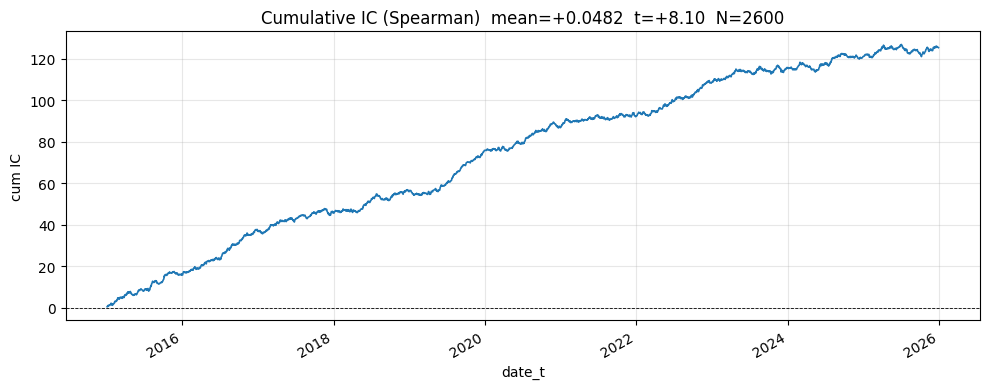

In [10]:
# SECTION 2D — Cell 13: Information Coefficient (IC)
# 各営業日 t について、signal_t (17銘柄) と realized_oc[t+1] (17銘柄) の
# Spearman 順位相関を計算。全期間の IC 系列から平均・std・t値を算出する。
#
# 合格ライン (要件定義書 v3 §4.1):
#   - 平均 IC が正
#   - t 値 (mean / (std / sqrt(N))) > 2

# signal_df.index = date_t、realized_df.index = date_t1 (= t+1)
# 行は順序的に1:1対応している（同じバックテストループから生成）。
# 銘柄方向の順位相関なので、signal の値とリターンの値を行ごとに直接 spearmanr に渡す。
assert len(signal_df) == len(realized_df), "signal/realized length mismatch"
assert list(signal_df.columns) == list(realized_df.columns) == list(JP_TICKERS)

sig_arr = signal_df.to_numpy()        # (N, 17)
oc_arr  = realized_df.to_numpy()      # (N, 17)
N_BT = sig_arr.shape[0]

ic_values = np.empty(N_BT, dtype=float)
for i in range(N_BT):
    # 17 銘柄方向の Spearman 順位相関
    rho, _ = spearmanr(sig_arr[i], oc_arr[i])
    ic_values[i] = rho

# NaN 行（理論上は発生しないはずだが念のため）の除外
ic_clean = ic_values[~np.isnan(ic_values)]
ic_series = pd.Series(ic_values, index=signal_df.index, name="IC")

ic_mean = float(ic_clean.mean())
ic_std  = float(ic_clean.std(ddof=1))
ic_n    = int(ic_clean.size)
ic_t    = ic_mean / (ic_std / np.sqrt(ic_n)) if ic_std > 0 else np.nan

ic_pass_sign = ic_mean > 0.0
ic_pass_tval = ic_t > 2.0
ic_pass      = ic_pass_sign and ic_pass_tval

print(f"IC samples (non-NaN)  : {ic_n} / {N_BT}")
print(f"IC mean               : {ic_mean:+.6f}")
print(f"IC std  (ddof=1)      : {ic_std:.6f}")
print(f"IC t-stat (mean/SE)   : {ic_t:+.3f}    [pass: > 2]")
print(f"  pass (mean > 0)     : {ic_pass_sign}")
print(f"  pass (t  > 2)       : {ic_pass_tval}")
print(f"  → CELL 13 verdict   : {'PASS' if ic_pass else 'FAIL'}")

# 累積 IC の可視化（右肩上がりなら予測力が安定している）
fig, ax = plt.subplots(figsize=(10, 4))
ic_series.cumsum().plot(ax=ax, color="#1f77b4", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Cumulative IC (Spearman)  mean={ic_mean:+.4f}  t={ic_t:+.2f}  N={ic_n}")
ax.set_xlabel("date_t")
ax.set_ylabel("cum IC")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Quintile (1=lowest signal, 5=highest)  daily OC mean (×100) :
  Q1: count=  10448  mean=-0.1094%  ann≈-27.56%
  Q2: count=   7836  mean=-0.0771%  ann≈-19.43%
  Q3: count=  10448  mean=-0.0548%  ann≈-13.82%
  Q4: count=   7836  mean=-0.0189%  ann≈-4.75%
  Q5: count=   7836  mean=+0.0156%  ann≈+3.94%
Q5 − Q1 spread (daily) : +0.1250%  (ann≈+31.50%)
Number of upward diffs : 4 / 4
  → CELL 14 verdict     : PASS (Q5>Q1 and ≥3 of 4 diffs positive)


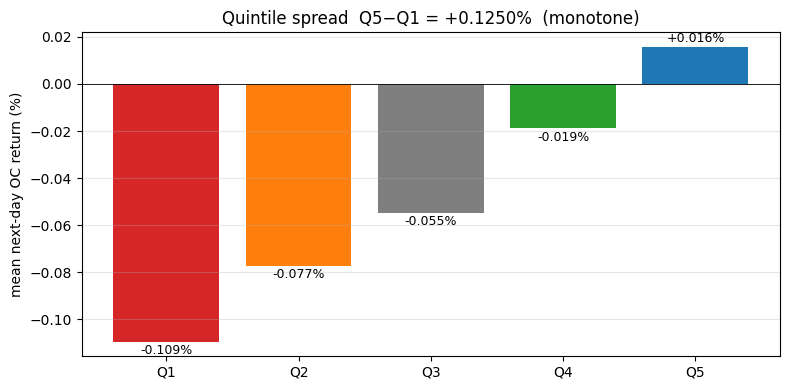

In [11]:
# SECTION 2D — Cell 14: Quintile spread
# 各日、signal_t で日本 17 銘柄を 5 分位に分割（rank-based、Q1 = 最低 〜 Q5 = 最高）。
# 各分位の平均翌日 OC リターンを全期間で集計し、単調性を確認する。
#
# 合格ライン (要件定義書 v3 §4.1):
#   - 上位分位 (Q5) > 下位分位 (Q1)
#   - 概ね単調（Q1 ≤ Q2 ≤ … ≤ Q5 が望ましい）

N_Q = 5
# 1 行 (=1 日) ごとに 17 銘柄を順位で 5 分位にビン分けする。
# scipy.stats.rankdata より numpy.argsort で十分（同値はランダム順だが影響は小さい）
# pandas.qcut を使うと境界の処理が分位サイズ非整数（17/5=3.4）でやや面倒なため、
# rank → floor((rank-1) / (17/5)) で安全にビン化する。
ranks = np.argsort(np.argsort(sig_arr, axis=1), axis=1)  # 0..16 ranks per row
bins  = np.minimum((ranks * N_Q) // sig_arr.shape[1], N_Q - 1)  # 0..N_Q-1

# 各分位の平均 OC リターン（全期間プール）
quintile_mean = np.empty(N_Q, dtype=float)
quintile_count = np.empty(N_Q, dtype=int)
for q in range(N_Q):
    mask = (bins == q)
    quintile_count[q] = int(mask.sum())
    quintile_mean[q]  = float(oc_arr[mask].mean()) if mask.any() else np.nan

# 単調性チェック
spread_q5_q1 = float(quintile_mean[N_Q - 1] - quintile_mean[0])
diffs        = np.diff(quintile_mean)
n_up         = int((diffs > 0).sum())
mono_pass    = (spread_q5_q1 > 0.0) and (n_up >= 3)  # 4 差分のうち 3 以上が正なら「概ね単調」

# 年率換算（参考表示用）：分位リターンは「ロング/ショート対象 1 銘柄あたり 1 日の OC」
ann_mean = quintile_mean * 252.0

print("Quintile (1=lowest signal, 5=highest)  daily OC mean (×100) :")
for q in range(N_Q):
    print(f"  Q{q+1}: count={quintile_count[q]:>7}  mean={quintile_mean[q]*100:+.4f}%  ann≈{ann_mean[q]*100:+.2f}%")
print(f"Q5 − Q1 spread (daily) : {spread_q5_q1*100:+.4f}%  (ann≈{spread_q5_q1*252*100:+.2f}%)")
print(f"Number of upward diffs : {n_up} / {N_Q - 1}")
print(f"  → CELL 14 verdict     : {'PASS' if mono_pass else 'FAIL'} (Q5>Q1 and ≥3 of 4 diffs positive)")

# 可視化
fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(1, N_Q + 1)
colors = ["#d62728", "#ff7f0e", "#7f7f7f", "#2ca02c", "#1f77b4"]
ax.bar(xs, quintile_mean * 100, color=colors)
for x, v in zip(xs, quintile_mean * 100):
    ax.text(x, v + (0.001 if v >= 0 else -0.001), f"{v:+.3f}%", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(xs)
ax.set_xticklabels([f"Q{q}" for q in xs])
ax.set_ylabel("mean next-day OC return (%)")
ax.set_title(f"Quintile spread  Q5−Q1 = {spread_q5_q1*100:+.4f}%  ({'monotone' if mono_pass else 'non-monotone'})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# SECTION 2D — Cell 15: Look-ahead audit (shift)
# signal 系列を +1 営業日ずらすと、シグナル date_t を 1 日「遅らせて」評価する形になる。
# つまり「本来 t+1 のリターンを取るべきシグナルを t+2 のリターンに合わせる」ことで、
# 元の信号→翌日リターンという正しい時間関係を崩す。
# リーク (未来情報の混入) があれば、ずらしてもパフォーマンスが崩れない or 改善する。
#
# 合格ライン (要件定義書 v3 §4.1): シフトでパフォーマンスが大きく低下する。

def _ann_metrics(daily: np.ndarray) -> dict:
    daily = np.asarray(daily, dtype=float)
    daily = daily[~np.isnan(daily)]
    if daily.size == 0:
        return dict(AR=np.nan, RISK=np.nan, RR=np.nan, N=0)
    ar   = float(daily.mean() * 252.0)
    risk = float(daily.std(ddof=1) * np.sqrt(252.0))
    rr   = ar / risk if risk > 0 else np.nan
    return dict(AR=ar, RISK=risk, RR=rr, N=int(daily.size))

def _strategy_returns_from_signal(sig: np.ndarray, oc: np.ndarray,
                                  q_long: int = 5, q_short: int = 5) -> np.ndarray:
    """sig[i] と oc[i] を行単位で対応させてロングショート P/L を計算する。

    sig: (N, 17)  ある時点 t における日本側スコア
    oc : (N, 17)  対応する時点で実現させる OC リターン (シフト試験では再アサインする)
    戻り値: shape (N,) の戦略リターン系列。
    """
    assert sig.shape == oc.shape
    n_days, n_stk = sig.shape
    w_long  = +1.0 / q_long
    w_short = -1.0 / q_short
    out = np.empty(n_days, dtype=float)
    for i in range(n_days):
        order = np.argsort(-sig[i])
        long_idx  = order[:q_long]
        short_idx = order[-q_short:]
        w = np.zeros(n_stk)
        w[long_idx]  = w_long
        w[short_idx] = w_short
        out[i] = float(np.dot(w, oc[i]))
    return out

# (a) ベースライン：そのまま再計算（strategy_returns と一致するはず）
base_pnl = _strategy_returns_from_signal(sig_arr, oc_arr)
base_chk = np.allclose(base_pnl, strategy_returns.to_numpy())
assert base_chk, "Reconstructed baseline P/L does not match strategy_returns — implementation drift"

# (b) シフト：signal を 1 行先（未来）の OC に合わせる
#     具体的には oc_arr を 1 行ずらす（i 番目のシグナルに i+1 番目の OC を当てる）。
#     これにより signal_date < return_date は維持されるが「ペアが正しくない」状態になる。
sig_shift = sig_arr[:-1]            # 最後の 1 行を捨てる
oc_shift  = oc_arr[1:]              # 1 行先の OC
shift_pnl = _strategy_returns_from_signal(sig_shift, oc_shift)

m_base  = _ann_metrics(base_pnl)
m_shift = _ann_metrics(shift_pnl)
delta_rr = m_shift["RR"] - m_base["RR"]
shift_pass = (m_shift["RR"] < 0.5 * m_base["RR"]) if (m_base["RR"] is not np.nan and m_base["RR"] > 0) else False

print("Look-ahead audit (shift)")
print(f"  baseline       : AR={m_base['AR']*100:+.2f}%  RISK={m_base['RISK']*100:.2f}%  R/R={m_base['RR']:+.3f}  (N={m_base['N']})")
print(f"  shifted (+1)   : AR={m_shift['AR']*100:+.2f}%  RISK={m_shift['RISK']*100:.2f}%  R/R={m_shift['RR']:+.3f}  (N={m_shift['N']})")
print(f"  Δ R/R          : {delta_rr:+.3f}")
print(f"  baseline reproduces strategy_returns: {base_chk}")
print(f"  → CELL 15 verdict : {'PASS' if shift_pass else 'FAIL'}  (shifted R/R must be < 0.5 × baseline)")


Look-ahead audit (shift)
  baseline       : AR=+27.89%  RISK=10.51%  R/R=+2.653  (N=2612)
  shifted (+1)   : AR=+6.38%  RISK=10.68%  R/R=+0.597  (N=2611)
  Δ R/R          : -2.056
  baseline reproduces strategy_returns: True
  → CELL 15 verdict : PASS  (shifted R/R must be < 0.5 × baseline)


In [13]:
# SECTION 2D — Cell 16: Look-ahead audit (shuffle)
# 各日の signal を「銘柄方向に」ランダム並べ替え (per-row shuffle) して P/L 再計算する。
# 銘柄と OC リターンの正しい対応が壊れるため、IC・分位スプレッドが期待値ゼロになり、
# 結果として R/R もほぼゼロに収束するはず。
# シャッフルしても R/R が高いままなら、signal が銘柄情報を使っていない or 別の経路で
# 情報が漏れている疑い。
#
# 合格ライン (要件定義書 v3 §4.1): シャッフル後の R/R ≒ 0

rng_local = np.random.default_rng(RNG_SEED)   # seed 固定で再現性確保

# 各行（日）の銘柄インデックスを独立にシャッフル
sig_shuffled = sig_arr.copy()
for i in range(sig_shuffled.shape[0]):
    perm = rng_local.permutation(sig_shuffled.shape[1])
    sig_shuffled[i] = sig_arr[i, perm]

shuffle_pnl = _strategy_returns_from_signal(sig_shuffled, oc_arr)

m_shuf = _ann_metrics(shuffle_pnl)
shuffle_pass = abs(m_shuf["RR"]) < 0.5   # |R/R| < 0.5 をほぼゼロとみなす

print("Look-ahead audit (shuffle, seed=RNG_SEED)")
print(f"  baseline       : AR={m_base['AR']*100:+.2f}%  RISK={m_base['RISK']*100:.2f}%  R/R={m_base['RR']:+.3f}")
print(f"  shuffled       : AR={m_shuf['AR']*100:+.2f}%  RISK={m_shuf['RISK']*100:.2f}%  R/R={m_shuf['RR']:+.3f}  (N={m_shuf['N']})")
print(f"  → CELL 16 verdict : {'PASS' if shuffle_pass else 'FAIL'}  (|shuffled R/R| < 0.5)")


Look-ahead audit (shuffle, seed=RNG_SEED)
  baseline       : AR=+27.89%  RISK=10.51%  R/R=+2.653
  shuffled       : AR=+3.31%  RISK=8.43%  R/R=+0.393  (N=2612)
  → CELL 16 verdict : PASS  (|shuffled R/R| < 0.5)


## セル 17: 検証レイヤー合否判定（要件定義書 v3 §4.2）

このセルは Markdown で書かれているが、合否表は実行時の値で埋まらないため、
**判定ロジックは以下の Python セルで実行され、その出力を見て確認する**。
（Notebook の再現性を保つため、結果値はセル 13〜16 の実行後に出力される。）


In [14]:
# SECTION 2D — Cell 17: Final verdict (Python)
# セル 13〜16 のフラグを集約し、合否を判定する。
# 要件定義書 v3 §4.2 の合格条件 4 つすべてを満たす必要がある。

verdicts = {
    "IC (mean>0 & t>2)"       : (ic_pass,      f"mean={ic_mean:+.4f}, t={ic_t:+.2f}"),
    "Quintile spread monotone": (mono_pass,    f"Q5-Q1={spread_q5_q1*100:+.4f}%/d, up-diffs={n_up}/4"),
    "Look-ahead shift"        : (shift_pass,   f"baseline R/R={m_base['RR']:+.2f} → shift R/R={m_shift['RR']:+.2f}"),
    "Look-ahead shuffle"      : (shuffle_pass, f"shuffled R/R={m_shuf['RR']:+.2f}"),
}

overall = all(v[0] for v in verdicts.values())

print("=" * 72)
print("SECTION 2D — Validation layer verdict (requirements_v3 §4.2)")
print("=" * 72)
for k, (ok, msg) in verdicts.items():
    print(f"  [{'PASS' if ok else 'FAIL'}]  {k:30s}  {msg}")
print("-" * 72)
print(f"  OVERALL : {'PASS — proceed to SECTION 2E / 3' if overall else 'FAIL — do NOT proceed to SECTION 3 (requirements_v3 §4.2)'}")
print("=" * 72)

if not overall:
    print("\nHypotheses for failure (highest priority first):")
    if not shift_pass:
        print("  - Look-ahead bug: re-audit cell 11 standardization. The window")
        print("    statistics (mu_w, sigma_w) must NOT include data at index t.")
    if not shuffle_pass:
        print("  - Signal may not depend on ticker identity. Check that V_J columns")
        print("    differ across rows (i.e. PCA is actually using JP block).")
    if not ic_pass:
        print("  - IC near zero or negative: predictive power absent. Re-check the")
        print("    sign convention in compute_lead_lag_signal and ranking direction.")
    if not mono_pass:
        print("  - Quintile spread non-monotone: signal direction may be inconsistent.")


SECTION 2D — Validation layer verdict (requirements_v3 §4.2)
  [PASS]  IC (mean>0 & t>2)               mean=+0.0482, t=+8.10
  [PASS]  Quintile spread monotone        Q5-Q1=+0.1250%/d, up-diffs=4/4
  [PASS]  Look-ahead shift                baseline R/R=+2.65 → shift R/R=+0.60
  [PASS]  Look-ahead shuffle              shuffled R/R=+0.39
------------------------------------------------------------------------
  OVERALL : PASS — proceed to SECTION 2E / 3
